In [ ]:
import numpy as np
import math

class Value:

    def __init__(self,data, _children=(), _op='', label=''):
        self.data=data
        self.prev=set(_children)
        self.op=_op
        self.label=label
        self.grad=0.0
        self._backward=lambda: None


    def __repr__(self):
        return f'Value(data={self.data})'

    def __add__(self,other):
        other= other if isinstance(other,Value) else Value(other)
        out= Value(self.data+other.data,(self,other),'+')

        def _backward():
          self.grad+=1.0*out.grad
          other.grad+=1.0*out.grad
        out._backward = _backward
        return out

    def __mul__(self,other):
        other= other if isinstance(other,Value) else Value(other)
        out=Value(self.data*other.data,(self,other), '*')
        def _backward():
          self.grad += other.data*out.grad
          other.grad+=self.data*out.grad
        out._backward = _backward
        return out

    def __pow__(self,other):
        assert isinstance(other,(int, float)), "sadece int/float"
        out= Value(self.data**other, (self, ), f'**{other}')
        def _backward():
            self.grad += other * (self.data ** (other-1)) * out.grad
        out._backward = _backward
        return out

    def __neg__(self):
        return self*-1
    def __sub__(self,other):
        return self + (-other)

    def __rmul__(self,other):
        return self*other

    def __truediv__(self,other):
       return self * other**-1

    def exp(self):
       x=self.data
       out= Value( math.exp(x), (self, ), 'exp')
       def _backward():
         self.grad+= out.data*out.grad
       out._backward=_backward
       return out

    def tanh(self):
      x=self.data
      t= (math.exp(2*x)-1)/(math.exp(2*x)+1)
      out=Value(t, (self,), 'tanh')
      def _backward():
         self.grad+=(1-t**2) * out.grad
      out._backward=_backward
      return out

    def backward(self):

      topo=[]
      visited= set()
      def build_topo(v):
         if v not in visited:
            visited.add(v)
            for child in v.prev:
               build_topo(child)
            topo.append(v)
      build_topo(self)

      self.grad=1.0
      for node in reversed(topo):
        node._backward()

a= Value(4.0,label='a')
b= Value(-3.0,label='b')
c= Value(12.0,label='c')
d= a+b
d.label='d'
e=d*c
e.label='e'

d, d.prev

(Value(data=1.0), {Value(data=-3.0), Value(data=4.0)})

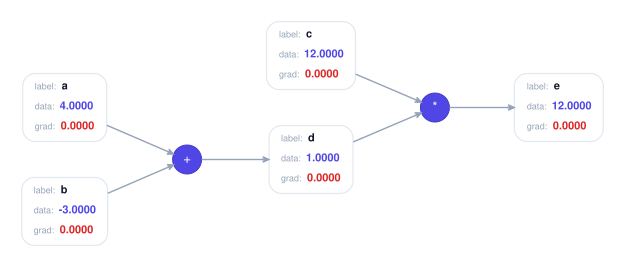

In [ ]:

from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v.prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_graph(root, format='png'):
    dot = Digraph(format=format, graph_attr={
        'rankdir': 'LR',
        'splines': 'spline',
        'nodesep': '0.5',
        'ranksep': '0.9',
        'bgcolor': 'transparent',
        'pad': '0.3'
    })

    dot.attr('node', fontname='Helvetica, Inter, Segoe UI, sans-serif', fontsize='11')
    dot.attr('edge', color='#94A3B8', penwidth='1.4', arrowsize='0.6', arrowhead='vee')

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        data_val = f"{n.data:.4f}" if isinstance(n.data, float) else f"{n.data}"
        grad_val = f"{n.grad:.4f}" if isinstance(n.grad, float) else f"{n.grad}"

        card_html = f'''<
        <TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" CELLPADDING="4" STYLE="ROUNDED" BGCOLOR="#FFFFFF">
            <TR><TD ALIGN="LEFT"><FONT COLOR="#94A3B8" POINT-SIZE="9">label:</FONT> <FONT COLOR="#0F172A" POINT-SIZE="11"><B>{n.label if n.label else "-"}</B></FONT></TD></TR>
            <TR><TD ALIGN="LEFT"><FONT COLOR="#94A3B8" POINT-SIZE="9">data:</FONT> <FONT COLOR="#4F46E5" POINT-SIZE="11"><B>{data_val}</B></FONT></TD></TR>
            <TR><TD ALIGN="LEFT"><FONT COLOR="#94A3B8" POINT-SIZE="9">grad:</FONT> <FONT COLOR="#DC2626" POINT-SIZE="11"><B>{grad_val}</B></FONT></TD></TR>
        </TABLE>>'''

        dot.node(
            name=uid,
            label=card_html,
            shape='box',
            style='rounded,filled',
            color='#E2E8F0',
            fillcolor='#FFFFFF',
            penwidth='1.2'
        )

        if n.op:
            op_id = uid + n.op
            dot.node(
                name=op_id,
                label=n.op,
                shape='circle',
                width='0.4',
                fixedsize='true',
                style='filled',
                fillcolor='#4F46E5',
                fontcolor='#FFFFFF',
                color='#4338CA',
                fontsize='13',
                fontname='Helvetica, sans-serif'
            )
            dot.edge(op_id, uid)
            for child in n.prev:
                dot.edge(str(id(child)), op_id)

    for child, parent in edges:
        if not parent.op:
            dot.edge(str(id(child)), str(id(parent)))

    return dot

dot = draw_graph(e)
dot.render('output_graph', view=True)
dot

In [ ]:
def lol():
    h=0.001
    a= Value(4.0,label='a')
    b= Value(-3.0,label='b')
    c= Value(12.0,label='c')
    d= a+b
    d.label='d'
    e=d*c
    e.label='e'
    e1=e.data

    a= Value(4.0,label='a')
    #a.data+=h
    b= Value(-3.0,label='b')
    #b.data+=h
    c= Value(12.0,label='c')
    #c.data+=h
    d= a+b
    #d.data+=h
    d.label='d'
    e=d*c
    #e.data +=h
    e.label='e'
    e2=e.data

    print((e2-e1)/h)
lol()

0.0


In [ ]:
d.grad=12.0
a.grad=12.0
b.grad=12.0
c.grad=1.0
e.grad=1.0

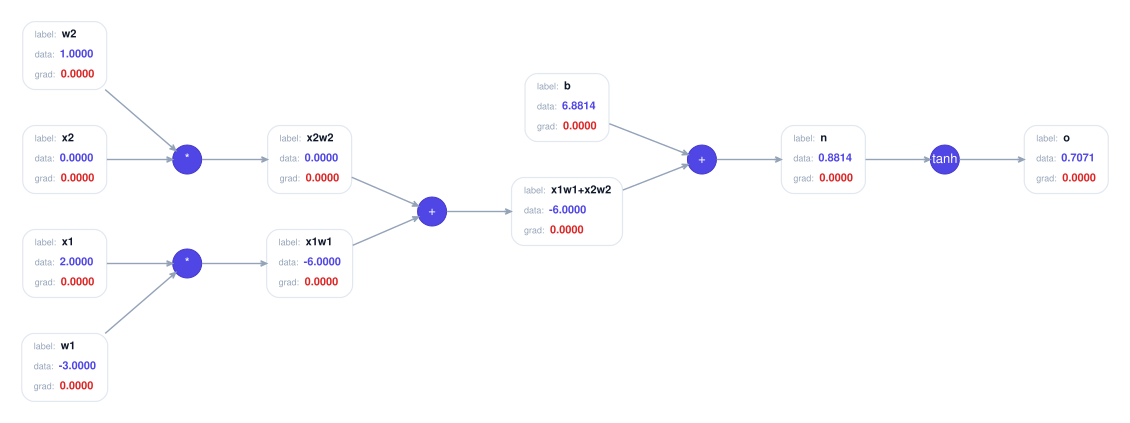

In [ ]:
x1=Value(2.0, label='x1')
x2=Value(0.0, label='x2')
w1=Value(-3.0, label='w1')
, label='w2')
bias=Value(6.8813735870195432, label='b')
x1w1=x1*w1; x1w1.label='x1w1'
x2w2=x2*w2; x2w2.label='x2w2'
x1w1x2w2= x1w1+x2w2; x1w1x2w2.label='x1w1+x2w2'
n=x1w1x2w2+bias; n.label='n'
o=n.tanh()
o.label='o'
draw_graph(o)

In [ ]:
#1-o.data**2 bu n'nin gradı
#n.grad=0.5
#x1w1x2w2.grad=0.5
#bias.grad=0.5
#x1w1.grad=0.5
#x2w2.grad=0.5

#x1.grad= w1.data*x1w1.grad
#w1.grad= x1.data*x1w1.grad

#x2.grad= w2.data*x2w2.grad
#w2.grad= x2.data*x2w2.grad

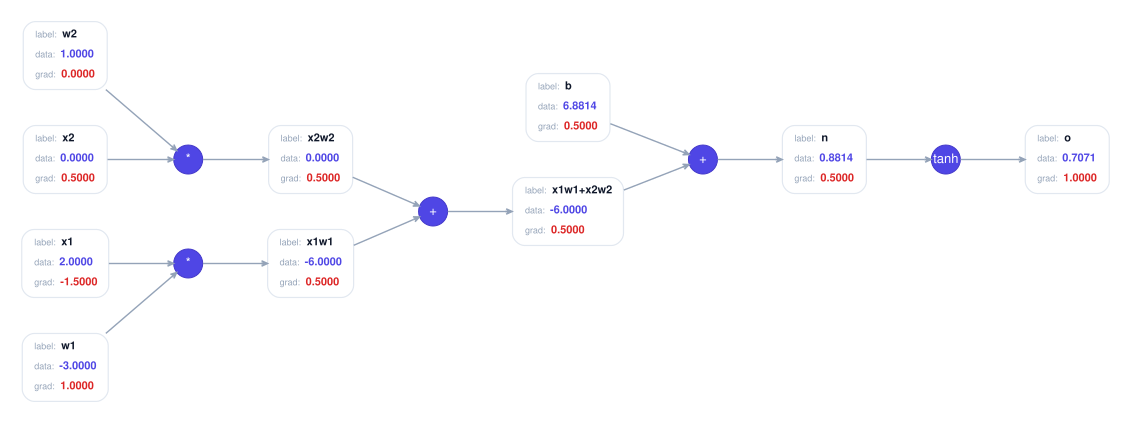

In [ ]:
draw_graph(o)

In [ ]:
o.backward()

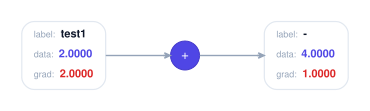

In [ ]:
test1= Value(2.0, label='test1')
test2= test1+test1
test2.backward()
draw_graph(test2)

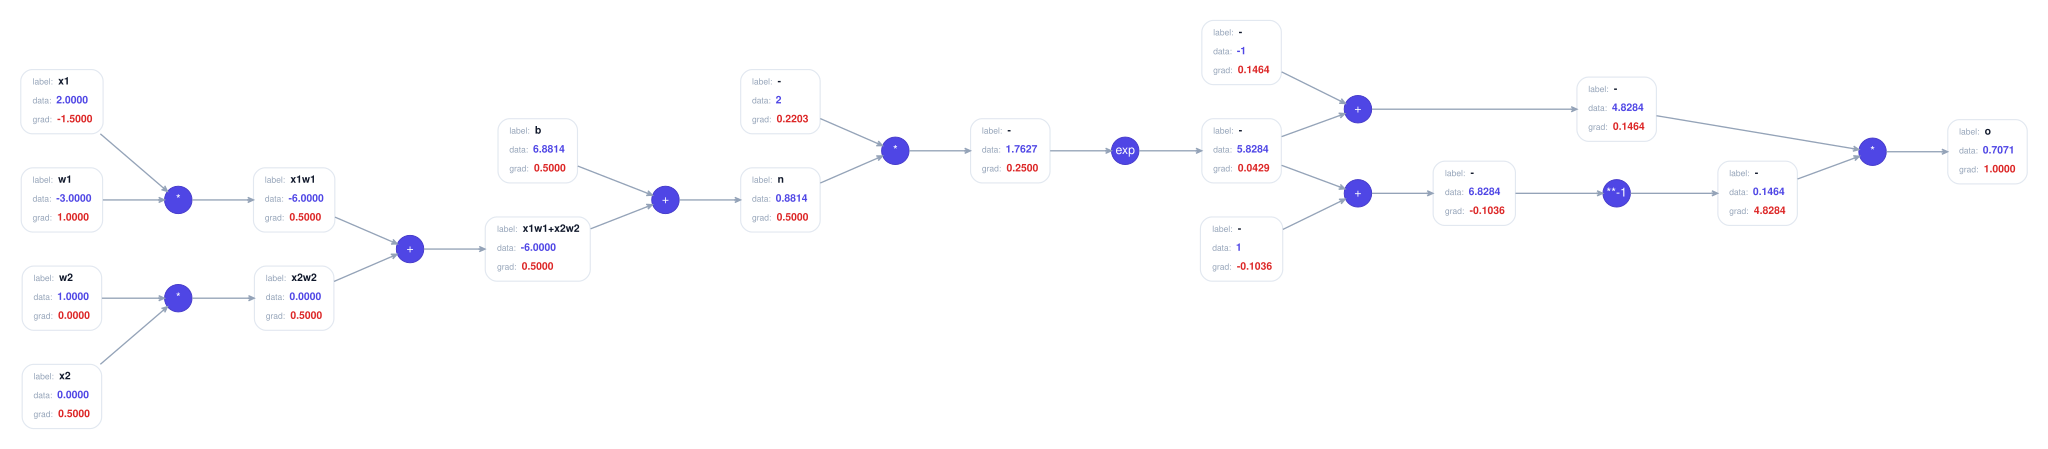

In [ ]:
x1=Value(2.0, label='x1')
x2=Value(0.0, label='x2')
w1=Value(-3.0, label='w1')
w2=Value(1.0, label='w2')
bias=Value(6.8813735870195432, label='b')
x1w1=x1*w1; x1w1.label='x1w1'
x2w2=x2*w2; x2w2.label='x2w2'
x1w1x2w2= x1w1+x2w2; x1w1x2w2.label='x1w1+x2w2'
n=x1w1x2w2+bias; n.label='n'
q= (2*n).exp()
o=(q-1) / (q+1)
o.label='o'
o.backward()
draw_graph(o)

In [ ]:
import torch

x1 = torch.tensor(2.0, requires_grad=True)
x2 = torch.tensor(0.0, requires_grad=True)
w1 = torch.tensor(-3.0, requires_grad=True)
w2 = torch.tensor(1.0, requires_grad=True)
bias = torch.tensor(6.8813735870195432, requires_grad=True)

n = x1*w1 + x2*w2 + bias
o = torch.tanh(n)
o.backward()

print(x1.grad.item(), w1.grad.item(), x2.grad.item(), w2.grad.item(), bias.grad.item())

-1.5000003576278687 1.000000238418579 0.5000001192092896 0.0 0.5000001192092896


In [ ]:
import random

class Neuron:

   def __init__(self,nin):
     self.w= [Value(random.uniform(-1,1)) for _ in range(nin)]
     self.b= Value(random.uniform(-1,1))
   def __call__(self, x):
     act= sum((wi*xi for wi, xi in zip(self.w, x)),self.b)
     out= act.tanh()
     return out
   def parameters(self):
     return self.w + [self.b]

class Layer:
   def __init__(self, nin, nout):
     self.neurons=[Neuron(nin) for _ in range(nout)]

   def __call__(self, x):
     outs = [n(x) for n in self.neurons]
     return outs[0] if len(outs) == 1 else outs
   def parameters(self):
     return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
   def __init__(self, nin, nouts):
      sz= [nin]+nouts
      self.layers= [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
   def __call__(self, x):
      for layer in self.layers:
        x=layer(x)
      return x
   def parameters(self):
     return [p for layer in self.layers for p in layer.parameters()]


x= [2.0,3.0, -1.0]
n= MLP(3, [4,4,1])
n(x)

Value(data=0.7222874979428359)

In [ ]:
xs= [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys=[1.0, -1.0, -1.0, 1.0]
ypred= [n(x) for x in xs]
ypred

[Value(data=0.9221406121083746),
 Value(data=-0.916408711371616),
 Value(data=-0.9023768765201774),
 Value(data=0.9242955258455958)]

0 0.0030674004313785107
1 0.0030563084991280286
2 0.0030452936208911433
3 0.003034355007733804
4 0.0030234918813772274
5 0.0030127034740194255
6 0.0030019890281602554
7 0.0029913477964299924
8 0.0029807790414212994
9 0.0029702820355244465
10 0.0029598560607659
11 0.0029495004086499974
12 0.0029392143800037384
13 0.0029289972848246647
14 0.0029188484421316364
15 0.0029087671798184674
16 0.0028987528345105562
17 0.0028888047514240484
18 0.002878922284227955
19 0.0028691047949086935


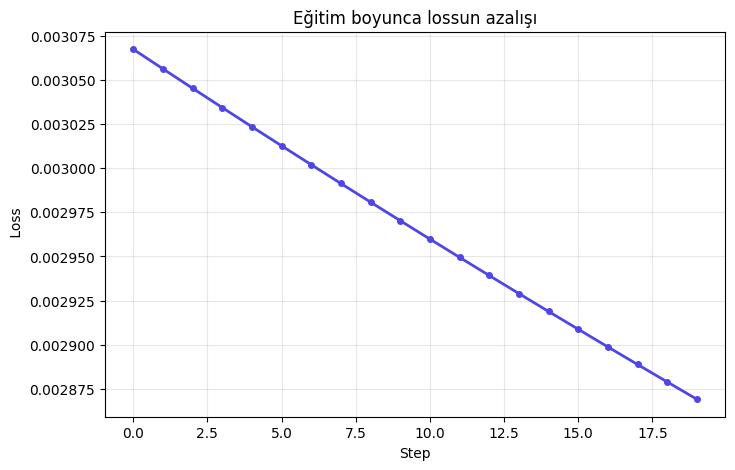

In [ ]:

import matplotlib.pyplot as plt

losses = []

for k in range(20):

    for p in n.parameters():
        p.grad = 0.0

    ypred = [n(x) for x in xs]
    loss = sum(((yout-ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0.0))

    loss.backward()

    for p in n.parameters():
        p.data += -0.05 * p.grad

    losses.append(loss.data)
    print(k, loss.data)

plt.figure(figsize=(8, 5))
plt.plot(losses, marker='o', color='#4F46E5', linewidth=2, markersize=4)
plt.xlabel('Step')
plt.ylabel(' Loss')
plt.title('Eğitim boyunca lossun azalışı')
plt.grid(True, alpha=0.3)
plt.show()

0 5.935628224387905
1 4.458904235619794
2 4.080989044045607
3 4.011984557135297
4 3.963533167294445
5 3.9199698223139765
6 3.8782132534296054
7 3.8371272383530495
8 3.796058008563271
9 3.754572893365514
10 3.7124065039747762
11 3.669437941577499
12 3.6256734596423454
13 3.58122561807204
14 3.536287999427384
15 3.4911054492436513
16 3.4459421451926957
17 3.4010503375517915
18 3.3566428319015515
19 3.312871408611755
20 3.2698120143989895
21 3.227455994625636
22 3.1857053466373424
23 3.144369179344806
24 3.103158248617924
25 3.061674388736762
26 3.01939160497212
27 2.9756253356001685
28 2.929485938576657
29 2.879812219988423
30 2.825082091927527
31 2.7633034827197434
32 2.6919066314725697
33 2.607702077082457
34 2.507051551892487
35 2.3865029681581262
36 2.244114482420438
37 2.0811803368572472
38 1.902999568352467
39 1.7171487333449948
40 1.5303549137440422
41 1.3475195391830175
42 1.173307452834322
43 1.0128893868865947
44 0.8705832376802373
45 0.7483366889055855
46 0.6455988294403585
47

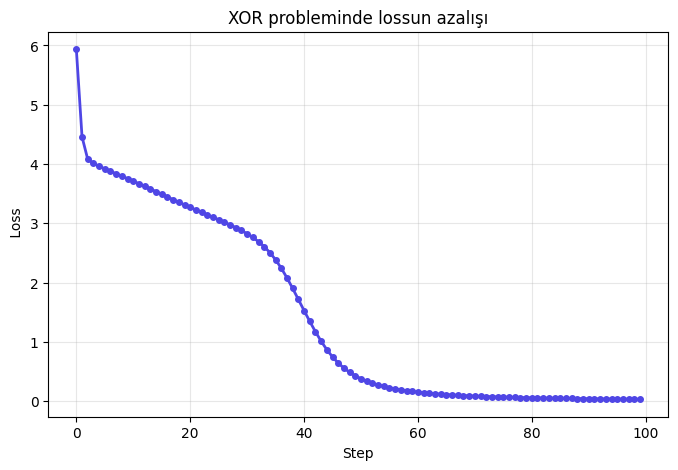

[0.0, 0.0] → Tahmin: -0.9175351253740248 | gerçek: -1.0
[0.0, 1.0] → Tahmin: 0.8818060111891785 | gerçek: 1.0
[1.0, 0.0] → Tahmin: 0.9062012738646142 | gerçek: 1.0
[1.0, 1.0] → Tahmin: -0.9293870499901808 | gerçek: -1.0


In [ ]:
#Farklı bir veri setiyle pekiştirme amaçlı
n = MLP(2, [4, 4, 1])
xs = [
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
]
ys = [-1.0, 1.0, 1.0, -1.0]
losses = []
for k in range(100):

    for p in n.parameters():
        p.grad = 0.0

    ypred = [n(x) for x in xs]
    loss = sum(((yout-ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0.0))

    loss.backward()

    for p in n.parameters():
        p.data += -0.05 * p.grad

    losses.append(loss.data)
    print(k, loss.data)

plt.figure(figsize=(8, 5))
plt.plot(losses, marker='o', color='#4F46E5', linewidth=2, markersize=4)
plt.xlabel('Step')
plt.ylabel(' Loss')
plt.title('XOR probleminde lossun azalışı')
plt.grid(True, alpha=0.3)
plt.show()

for x, y in zip(xs, ys):
    print(x, '→ Tahmin:', n(x).data, '| gerçek:', y)